# Smart Factory Machinery Predictor


### Library Imports

In [163]:
import pandas as pd      
import numpy as np        
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import OneHotEncoder
import joblib
import warnings
warnings.filterwarnings('ignore')

Load Dataset and Processing

In [164]:

df = pd.read_csv('smart factory machinery data set.csv')
print("Dataset loaded successfully.")
print(f"Shape of dataset: {df.shape}")


Dataset loaded successfully.
Shape of dataset: (10000, 14)


In [165]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [166]:
df.tail()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0
9999,10000,M24859,M,299.0,308.7,1500,40.2,30,0,0,0,0,0,0


In [167]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [168]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [169]:
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

Total Rows: 10000
Total Columns: 14


In [170]:
print("Missing Values Per Column:")
print(df.isnull().sum())

Missing Values Per Column:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [171]:
print(f"\nTotal Missing Values: {df.isnull().sum().sum()}")


Total Missing Values: 0


In [172]:
duplicate_count = df.duplicated().sum()
print(f"Number of Duplicate Rows: {duplicate_count}")

Number of Duplicate Rows: 0


In [173]:
print("Value Counts for 'Type' column:")
print(df['Type'].value_counts())

Value Counts for 'Type' column:
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


In [174]:
print("Value Counts for 'Machine failure' column:")
print(df['Machine failure'].value_counts())

Value Counts for 'Machine failure' column:
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [175]:
df = df.drop_duplicates()
print(f"Rows after removing duplicates: {df.shape[0]}")

Rows after removing duplicates: 10000


---
## Task 1: Linear Regression


In [176]:
X = df[['Rotational speed [rpm]']]
y = df['Process temperature [K]']
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


X shape: (10000, 1)
y shape: (10000,)


In [177]:
model_simple = LinearRegression()
model_simple.fit(X, y)
print(f"Model Coefficient (Slope): {model_simple.coef_[0]:.4f}")
print(f"Model Intercept: {model_simple.intercept_:.4f}")

Model Coefficient (Slope): 0.0002
Model Intercept: 309.7601


In [178]:
y_pred_simple = model_simple.predict(X)
mse_simple = mean_squared_error(y, y_pred_simple)
print(f"Simple Linear Regression MSE: {mse_simple:.4f}")
print(f"Simple Linear Regression RMSE: {mse_simple**0.5:.4f}")

Simple Linear Regression MSE: 2.2004
Simple Linear Regression RMSE: 1.4834


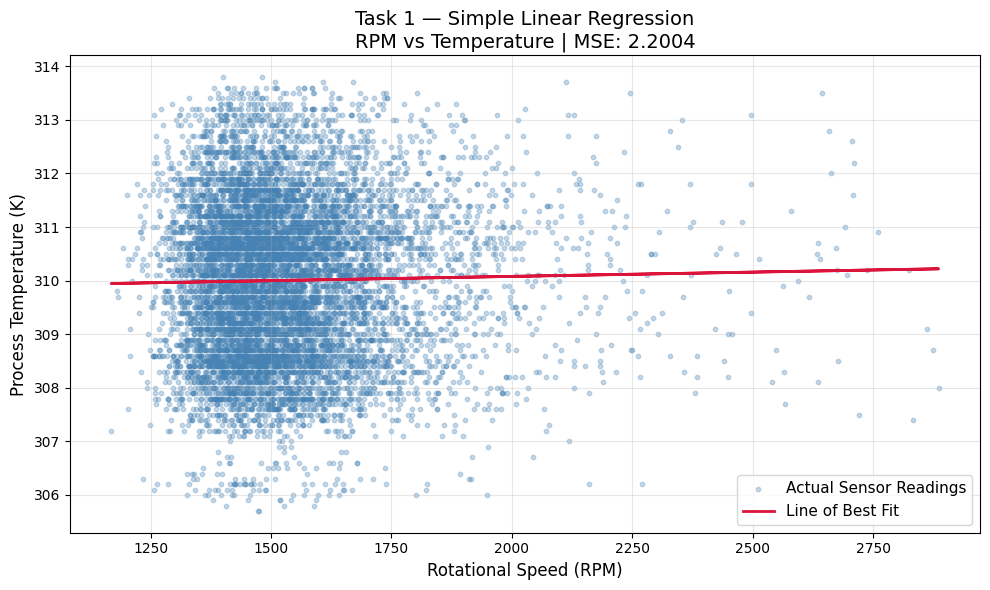

In [179]:
plt.figure(figsize=(10, 6))

plt.scatter(X, y, color='steelblue', alpha=0.3, s=10, label='Actual Sensor Readings')

plt.plot(X, y_pred_simple, color='crimson', linewidth=2, label='Line of Best Fit')

plt.xlabel('Rotational Speed (RPM)', fontsize=12)
plt.ylabel('Process Temperature (K)', fontsize=12)

plt.title(f'Task 1 — Simple Linear Regression\nRPM vs Temperature | MSE: {mse_simple:.4f}', fontsize=14)

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Task 2: Multivariable Regression


In [180]:

X_multi = df[['Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Air temperature [K]']]
y_multi = df['Process temperature [K]']
print(f"X_multi shape: {X_multi.shape}")
print(f"y_multi shape: {y_multi.shape}")
print("\nFeatures being used:")
for col in X_multi.columns:
    print(f"  — {col}")

X_multi shape: (10000, 4)
y_multi shape: (10000,)

Features being used:
  — Rotational speed [rpm]
  — Torque [Nm]
  — Tool wear [min]
  — Air temperature [K]


In [181]:
model_multi = LinearRegression()
model_multi.fit(X_multi, y_multi)
print("Learned Coefficients (Slopes) for each feature:")
for feature, coef in zip(X_multi.columns, model_multi.coef_):
    print(f"  {feature}: {coef:.6f}")
print(f"\nIntercept: {model_multi.intercept_:.4f}")

Learned Coefficients (Slopes) for each feature:
  Rotational speed [rpm]: -0.000082
  Torque [Nm]: -0.001587
  Tool wear [min]: 0.000031
  Air temperature [K]: 0.649915

Intercept: 115.2142


In [182]:
y_pred_multi = model_multi.predict(X_multi)
mse_multi = mean_squared_error(y_multi, y_pred_multi)
print(f"Task 1 MSE  (1 feature  — RPM only)     : {mse_simple:.4f}")
print(f"Task 2 MSE  (4 features — Multi)         : {mse_multi:.4f}")
print(f"Improvement : {mse_simple - mse_multi:.4f} reduction in error")


Task 1 MSE  (1 feature  — RPM only)     : 2.2004
Task 2 MSE  (4 features — Multi)         : 0.5116
Improvement : 1.6888 reduction in error


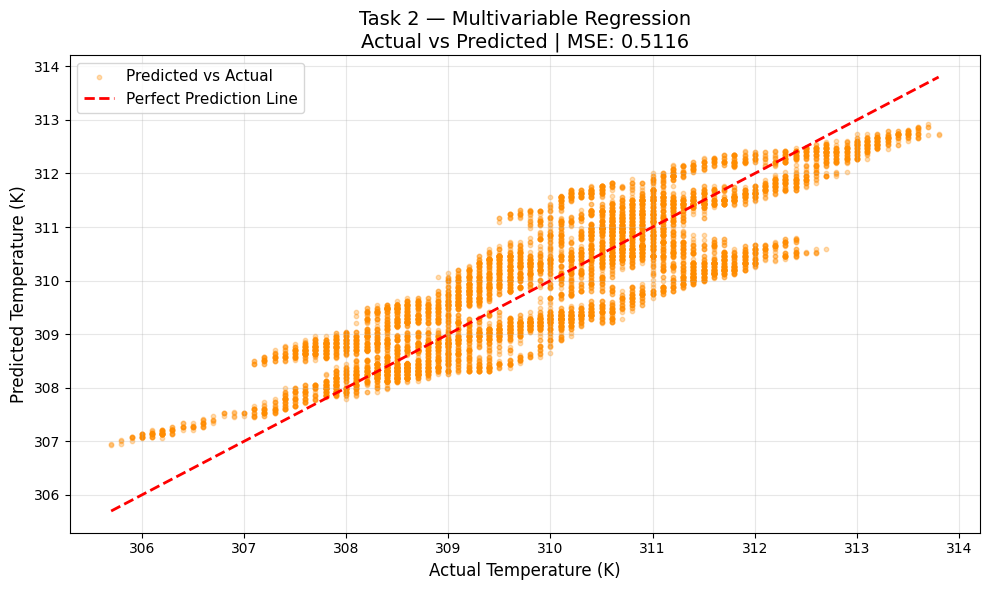

In [183]:
plt.figure(figsize=(10, 6))
plt.scatter(y_multi, y_pred_multi, color='darkorange', alpha=0.3, s=10, label='Predicted vs Actual')
min_val = min(y_multi.min(), y_pred_multi.min())
max_val = max(y_multi.max(), y_pred_multi.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linewidth=2, linestyle='--', label='Perfect Prediction Line')
plt.xlabel('Actual Temperature (K)', fontsize=12)
plt.ylabel('Predicted Temperature (K)', fontsize=12)
plt.title(f'Task 2 — Multivariable Regression\nActual vs Predicted | MSE: {mse_multi:.4f}', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

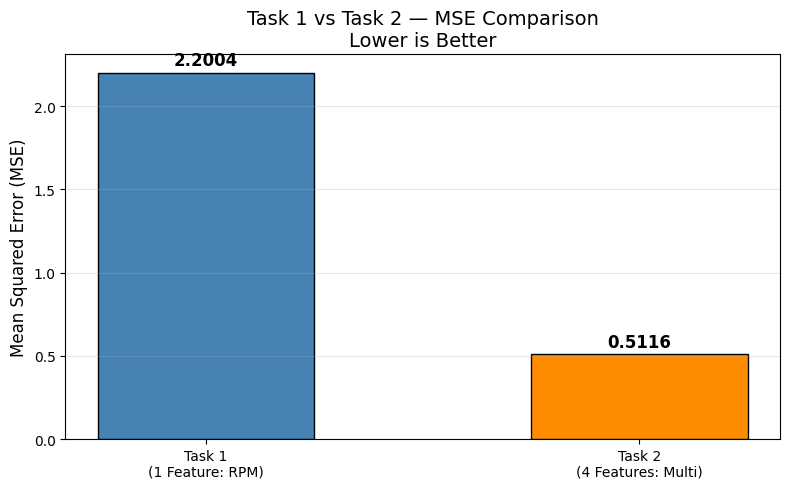

In [184]:
plt.figure(figsize=(8, 5))
tasks = ['Task 1\n(1 Feature: RPM)', 'Task 2\n(4 Features: Multi)']
mse_values = [mse_simple, mse_multi]
colors = ['steelblue', 'darkorange']

bars = plt.bar(tasks, mse_values, color=colors, width=0.5, edgecolor='black')
for bar, mse in zip(bars, mse_values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
             f'{mse:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.title('Task 1 vs Task 2 — MSE Comparison\nLower is Better', fontsize=14)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Task 3: Save and Load the Trained Model

In [185]:
import joblib
joblib.dump(model_multi, 'smart_factory_model.pkl')

['smart_factory_model.pkl']

In [186]:

new_machine_reading = pd.DataFrame({
    'Rotational speed [rpm]': [1500],
    'Torque [Nm]': [40],
    'Tool wear [min]': [120],
    'Air temperature [K]': [300]
})
print("Mock new machine reading:")
print(new_machine_reading)

Mock new machine reading:
   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Air temperature [K]
0                    1500           40              120                  300


In [187]:
loaded_model = joblib.load('smart_factory_model.pkl')
predicted_temp = loaded_model.predict(new_machine_reading)
print(f"Predicted Process Temperature: {predicted_temp[0]:.2f} K")
print(f"Predicted Process Temperature: {predicted_temp[0] - 273.15:.2f} °C")

Predicted Process Temperature: 310.01 K
Predicted Process Temperature: 36.86 °C


In [188]:

original_pred = model_multi.predict(new_machine_reading)
loaded_pred = loaded_model.predict(new_machine_reading)
print(f"Original model prediction : {original_pred[0]:.6f} K")
print(f"Loaded model prediction   : {loaded_pred[0]:.6f} K")
print(f"Difference                : {abs(original_pred[0] - loaded_pred[0]):.10f}")


Original model prediction : 310.005888 K
Loaded model prediction   : 310.005888 K
Difference                : 0.0000000000


In [189]:
import pickle
with open('model_pickle', 'wb') as file:
    pickle.dump(model_multi, file)

print("Model saved successfully using Pickle.")
import os
print(f"Pickle file size: {os.path.getsize('model_pickle')} bytes")

Model saved successfully using Pickle.
Pickle file size: 633 bytes


In [190]:

with open('model_pickle', 'rb') as file:
    mp = pickle.load(file)

print(f"\nOriginal model coefficients  : {model_multi.coef_}")
print(f"Pickle loaded  coefficients  : {mp.coef_}")

print(f"\nOriginal model intercept     : {model_multi.intercept_:.6f}")
print(f"Pickle loaded  intercept     : {mp.intercept_:.6f}")

pickle_pred = mp.predict(new_machine_reading)
print(f"\nOriginal model prediction    : {original_pred[0]:.6f} K")
print(f"Pickle loaded  prediction    : {pickle_pred[0]:.6f} K")
print(f"Difference                   : {abs(original_pred[0] - pickle_pred[0]):.10f}")



Original model coefficients  : [-8.20600778e-05 -1.58677594e-03  3.07535752e-05  6.49915258e-01]
Pickle loaded  coefficients  : [-8.20600778e-05 -1.58677594e-03  3.07535752e-05  6.49915258e-01]

Original model intercept     : 115.214181
Pickle loaded  intercept     : 115.214181

Original model prediction    : 310.005888 K
Pickle loaded  prediction    : 310.005888 K
Difference                   : 0.0000000000


In [191]:

mj = joblib.load('smart_factory_model.pkl')

print("Model loaded successfully using joblib.")

print(f"\nOriginal model coefficients  : {model_multi.coef_}")
print(f"Joblib loaded  coefficients  : {mj.coef_}")


print(f"\nOriginal model intercept     : {model_multi.intercept_:.6f}")
print(f"Joblib loaded  intercept     : {mj.intercept_:.6f}")

joblib_pred = mj.predict(new_machine_reading)
print(f"\nOriginal model prediction    : {original_pred[0]:.6f} K")
print(f"Joblib loaded  prediction    : {joblib_pred[0]:.6f} K")
print(f"Difference                   : {abs(original_pred[0] - joblib_pred[0]):.10f}")

Model loaded successfully using joblib.

Original model coefficients  : [-8.20600778e-05 -1.58677594e-03  3.07535752e-05  6.49915258e-01]
Joblib loaded  coefficients  : [-8.20600778e-05 -1.58677594e-03  3.07535752e-05  6.49915258e-01]

Original model intercept     : 115.214181
Joblib loaded  intercept     : 115.214181

Original model prediction    : 310.005888 K
Joblib loaded  prediction    : 310.005888 K
Difference                   : 0.0000000000


---
## Task 4: One-Hot Encoding

In [192]:

print("Sample values in 'Type' column:")
print(df['Type'].head(10))

print(f"\nUnique categories: {df['Type'].unique()}")
print(f"\nValue counts:")
print(df['Type'].value_counts())


Sample values in 'Type' column:
0    M
1    L
2    L
3    L
4    L
5    M
6    L
7    L
8    M
9    M
Name: Type, dtype: str

Unique categories: <ArrowStringArray>
['M', 'L', 'H']
Length: 3, dtype: str

Value counts:
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


In [193]:

df_encoded = pd.get_dummies(df, columns=['Type'], drop_first=True)

print("Original columns:")
print(df.columns.tolist())
print(f"\nEncoded columns:")
print(df_encoded.columns.tolist())
print(f"\nNew columns added by encoding:")
new_cols = [col for col in df_encoded.columns if col.startswith('Type')]
print(new_cols)

Original columns:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Encoded columns:
['UDI', 'Product ID', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Type_L', 'Type_M']

New columns added by encoding:
['Type_L', 'Type_M']


In [194]:
print("Sample of encoded Type columns:")
print(df_encoded[new_cols + ['Process temperature [K]']].head(10))

print(f"\nShape before encoding: {df.shape}")
print(f"Shape after encoding : {df_encoded.shape}")

Sample of encoded Type columns:
   Type_L  Type_M  Process temperature [K]
0   False    True                    308.6
1    True   False                    308.7
2    True   False                    308.5
3    True   False                    308.6
4    True   False                    308.7
5   False    True                    308.6
6    True   False                    308.6
7    True   False                    308.6
8   False    True                    308.7
9   False    True                    309.0

Shape before encoding: (10000, 14)
Shape after encoding : (10000, 15)


In [195]:

comparison = pd.DataFrame({
    'Original_Type': df['Type'].head(8).values,
    'Type_L': df_encoded['Type_L'].head(8).values,
    'Type_M': df_encoded['Type_M'].head(8).values
})

print("Before and After One-Hot Encoding:")
print(comparison.to_string(index=True))


Before and After One-Hot Encoding:
  Original_Type  Type_L  Type_M
0             M   False    True
1             L    True   False
2             L    True   False
3             L    True   False
4             L    True   False
5             M   False    True
6             L    True   False
7             L    True   False


In [196]:
df_clean = pd.read_csv('smart factory machinery data set.csv')
df_clean = df_clean.drop(columns=['UDI', 'Product ID'])
dummies = pd.get_dummies(df_clean['Type'])
print("Dummy columns created separately:")
print(dummies.head(8))

Dummy columns created separately:
       H      L      M
0  False  False   True
1  False   True  False
2  False   True  False
3  False   True  False
4  False   True  False
5  False  False   True
6  False   True  False
7  False   True  False


In [197]:
df_merged = pd.concat([df_clean, dummies], axis=1)
print("After concatenation — new shape:", df_merged.shape)
print("\nColumns now present:")
print(df_merged.columns.tolist())
print("\nSample of merged data (Type column + dummy columns):")
print(df_merged[['Type', 'H', 'L', 'M']].head(8))

After concatenation — new shape: (10000, 15)

Columns now present:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'H', 'L', 'M']

Sample of merged data (Type column + dummy columns):
  Type      H      L      M
0    M  False  False   True
1    L  False   True  False
2    L  False   True  False
3    L  False   True  False
4    L  False   True  False
5    M  False  False   True
6    L  False   True  False
7    L  False   True  False


In [198]:

df_merged = df_merged.drop(columns=['Type'])

print("After dropping original 'Type' column:")
print(df_merged.columns.tolist())

After dropping original 'Type' column:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'H', 'L', 'M']


In [199]:

df_manual_encoded = df_merged.drop(columns=['H'])

print("Final manually encoded DataFrame:")
print(df_manual_encoded.columns.tolist())
print(f"\nShape: {df_manual_encoded.shape}")
print("\nSample — L and M columns (H is the baseline when both are 0):")
print(df_manual_encoded[['L', 'M', 'Process temperature [K]']].head(10))

Final manually encoded DataFrame:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'L', 'M']

Shape: (10000, 13)

Sample — L and M columns (H is the baseline when both are 0):
       L      M  Process temperature [K]
0  False   True                    308.6
1   True  False                    308.7
2   True  False                    308.5
3   True  False                    308.6
4   True  False                    308.7
5  False   True                    308.6
6   True  False                    308.6
7   True  False                    308.6
8  False   True                    308.7
9  False   True                    309.0


In [200]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_label_test = df_clean.copy()

df_label_test['Type_encoded'] = le.fit_transform(df_label_test['Type'])

print("LabelEncoder result:")
print(df_label_test[['Type', 'Type_encoded']].head(10))
print(f"\nMapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")


LabelEncoder result:
  Type  Type_encoded
0    M             2
1    L             1
2    L             1
3    L             1
4    L             1
5    M             2
6    L             1
7    L             1
8    M             2
9    M             2

Mapping: {'H': 0, 'L': 1, 'M': 2}


In [201]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

X_raw = df_clean[['Type', 'Rotational speed [rpm]', 'Torque [Nm]', 
                   'Tool wear [min]', 'Air temperature [K]']]

ct = ColumnTransformer(
    [('type_encoder', OneHotEncoder(), [0])],
    remainder='passthrough'
)

X_ct = ct.fit_transform(X_raw)

print("Shape after ColumnTransformer encoding:", X_ct.shape)
print("\nFirst 5 rows of encoded array:")
print(X_ct[:5])

Shape after ColumnTransformer encoding: (10000, 7)

First 5 rows of encoded array:
[[0.000e+00 0.000e+00 1.000e+00 1.551e+03 4.280e+01 0.000e+00 2.981e+02]
 [0.000e+00 1.000e+00 0.000e+00 1.408e+03 4.630e+01 3.000e+00 2.982e+02]
 [0.000e+00 1.000e+00 0.000e+00 1.498e+03 4.940e+01 5.000e+00 2.981e+02]
 [0.000e+00 1.000e+00 0.000e+00 1.433e+03 3.950e+01 7.000e+00 2.982e+02]
 [0.000e+00 1.000e+00 0.000e+00 1.408e+03 4.000e+01 9.000e+00 2.982e+02]]


In [202]:

X_ct = X_ct[:, 1:]

print("Shape after dropping first dummy column:", X_ct.shape)
print("\nFirst 5 rows after dropping first column:")
print(X_ct[:5])

Shape after dropping first dummy column: (10000, 6)

First 5 rows after dropping first column:
[[0.000e+00 1.000e+00 1.551e+03 4.280e+01 0.000e+00 2.981e+02]
 [1.000e+00 0.000e+00 1.408e+03 4.630e+01 3.000e+00 2.982e+02]
 [1.000e+00 0.000e+00 1.498e+03 4.940e+01 5.000e+00 2.981e+02]
 [1.000e+00 0.000e+00 1.433e+03 3.950e+01 7.000e+00 2.982e+02]
 [1.000e+00 0.000e+00 1.408e+03 4.000e+01 9.000e+00 2.982e+02]]


In [203]:

from sklearn.linear_model import LinearRegression

X_enc = df_manual_encoded[['Rotational speed [rpm]', 'Torque [Nm]', 
                             'Tool wear [min]', 'Air temperature [K]', 'L', 'M']]

y_enc = df_manual_encoded['Process temperature [K]']

model_encoded = LinearRegression()
model_encoded.fit(X_enc, y_enc)

from sklearn.metrics import mean_squared_error
y_pred_enc = model_encoded.predict(X_enc)
mse_encoded = mean_squared_error(y_enc, y_pred_enc)

print(f"Task 1 MSE (1 feature, no encoding)     : {mse_simple:.4f}")
print(f"Task 2 MSE (4 features, no encoding)    : {mse_multi:.4f}")
print(f"Task 4 MSE (4 features + Type encoded)  : {mse_encoded:.4f}")

Task 1 MSE (1 feature, no encoding)     : 2.2004
Task 2 MSE (4 features, no encoding)    : 0.5116
Task 4 MSE (4 features + Type encoded)  : 0.5116


In [204]:

new_reading_encoded = pd.DataFrame({
    'Rotational speed [rpm]': [1500],
    'Torque [Nm]': [40],
    'Tool wear [min]': [120],
    'Air temperature [K]': [300],
    'L': [0],
    'M': [1]
})

pred_with_type = model_encoded.predict(new_reading_encoded)
print(f"Predicted Temperature (Type M machine): {pred_with_type[0]:.2f} K")
print(f"In Celsius: {pred_with_type[0] - 273.15:.2f} °C")

Predicted Temperature (Type M machine): 310.00 K
In Celsius: 36.85 °C


---
## Task 5: Train-Test Split

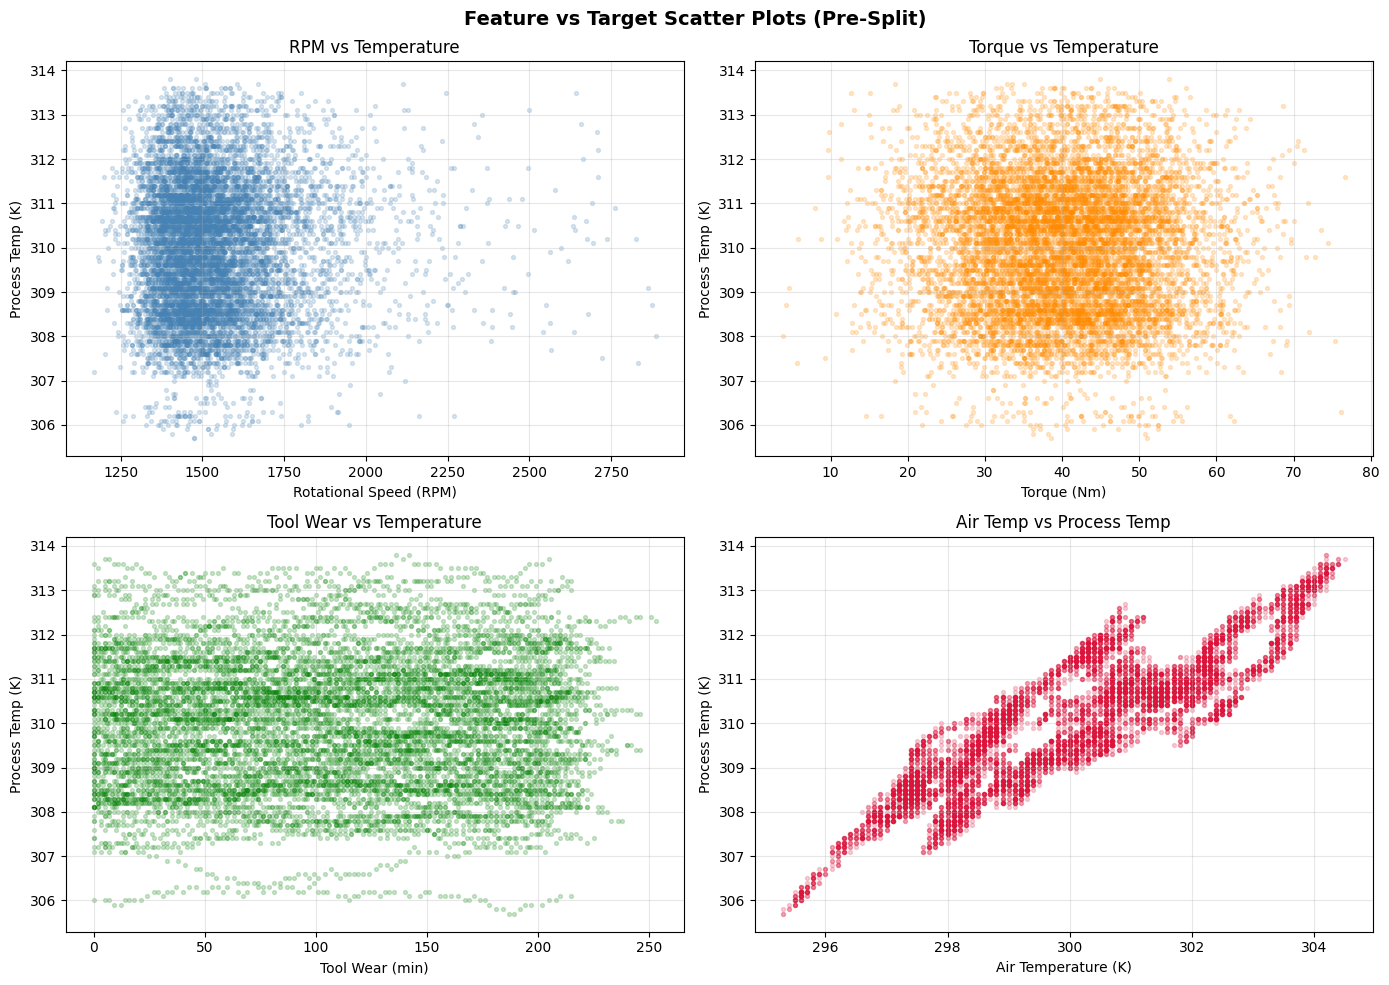

In [205]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0][0].scatter(df_encoded['Rotational speed [rpm]'],
                   df_encoded['Process temperature [K]'],
                   color='steelblue', alpha=0.2, s=8)
axes[0][0].set_xlabel('Rotational Speed (RPM)')
axes[0][0].set_ylabel('Process Temp (K)')
axes[0][0].set_title('RPM vs Temperature')
axes[0][0].grid(True, alpha=0.3)

axes[0][1].scatter(df_encoded['Torque [Nm]'],
                   df_encoded['Process temperature [K]'],
                   color='darkorange', alpha=0.2, s=8)
axes[0][1].set_xlabel('Torque (Nm)')
axes[0][1].set_ylabel('Process Temp (K)')
axes[0][1].set_title('Torque vs Temperature')
axes[0][1].grid(True, alpha=0.3)

axes[1][0].scatter(df_encoded['Tool wear [min]'],
                   df_encoded['Process temperature [K]'],
                   color='green', alpha=0.2, s=8)
axes[1][0].set_xlabel('Tool Wear (min)')
axes[1][0].set_ylabel('Process Temp (K)')
axes[1][0].set_title('Tool Wear vs Temperature')
axes[1][0].grid(True, alpha=0.3)

axes[1][1].scatter(df_encoded['Air temperature [K]'],
                   df_encoded['Process temperature [K]'],
                   color='crimson', alpha=0.2, s=8)
axes[1][1].set_xlabel('Air Temperature (K)')
axes[1][1].set_ylabel('Process Temp (K)')
axes[1][1].set_title('Air Temp vs Process Temp')
axes[1][1].grid(True, alpha=0.3)

plt.suptitle('Feature vs Target Scatter Plots (Pre-Split)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [206]:

X = df_encoded[['Rotational speed [rpm]', 'Torque [Nm]',
                 'Tool wear [min]', 'Air temperature [K]',
                 'Type_L', 'Type_M']]

y = df_encoded['Process temperature [K]']

print(f"X shape: {X.shape}")

print(f"y shape: {y.shape}")

print("\nFeatures included:")
for col in X.columns:
    print(f"  — {col}")

X shape: (10000, 6)
y shape: (10000,)

Features included:
  — Rotational speed [rpm]
  — Torque [Nm]
  — Tool wear [min]
  — Air temperature [K]
  — Type_L
  — Type_M


In [207]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Total dataset size   : {X.shape[0]} rows")
print(f"Training set size    : {X_train.shape[0]} rows ({X_train.shape[0]/X.shape[0]*100:.0f}%)")
print(f"Test set size        : {X_test.shape[0]} rows ({X_test.shape[0]/X.shape[0]*100:.0f}%)")

Total dataset size   : 10000 rows
Training set size    : 8000 rows (80%)
Test set size        : 2000 rows (20%)


In [208]:

print("X_train (first 6 rows):")
print(X_train.head(6))

X_train (first 6 rows):
      Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  \
9254                    1616         31.1              195   
1561                    1388         53.8              137   
1670                    1528         31.1              194   
6087                    1599         33.0                7   
6669                    1571         33.9              208   
5933                    1373         47.4               56   

      Air temperature [K]  Type_L  Type_M  
9254                298.3    True   False  
1561                298.2    True   False  
1670                298.2    True   False  
6087                300.9   False    True  
6669                301.4    True   False  
5933                300.5    True   False  


In [209]:
print("X_test (first 6 rows):")
print(X_test.head(6))

X_test (first 6 rows):
      Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  \
6252                    1538         36.1              198   
4684                    1421         44.8              101   
1731                    1485         42.0              117   
4742                    1592         33.7               14   
4521                    1865         23.9              129   
6340                    1397         45.9              210   

      Air temperature [K]  Type_L  Type_M  
6252                300.8    True   False  
4684                303.6   False    True  
1731                298.3   False    True  
4742                303.3    True   False  
4521                302.4    True   False  
6340                300.5   False   False  


In [210]:
print("y_test (first 6 actual temperature values):")
print(y_test.head(6))

y_test (first 6 actual temperature values):
6252    310.3
4684    311.8
1731    307.9
4742    311.3
4521    310.4
6340    309.9
Name: Process temperature [K], dtype: float64


In [211]:
from sklearn.linear_model import LinearRegression
clf = LinearRegression()
clf.fit(X_train, y_train)
print("Model trained on training set only.")
print(f"Training rows used: {X_train.shape[0]}")
print(f"Test rows hidden  : {X_test.shape[0]}")

Model trained on training set only.
Training rows used: 8000
Test rows hidden  : 2000


In [212]:
from sklearn.metrics import mean_squared_error
y_pred_test = clf.predict(X_test)
comparison_df = pd.DataFrame({
    'Actual Temperature (K)': y_test.values[:10],
    'Predicted Temperature (K)': y_pred_test[:10].round(2),
    'Error (K)': (y_test.values[:10] - y_pred_test[:10]).round(2)
})

print("Actual vs Predicted (first 10 test rows):")
print(comparison_df.to_string(index=False))

Actual vs Predicted (first 10 test rows):
 Actual Temperature (K)  Predicted Temperature (K)  Error (K)
                  310.3                     310.53      -0.23
                  311.8                     312.33      -0.53
                  307.9                     308.88      -0.98
                  311.3                     312.17      -0.87
                  310.4                     311.57      -1.17
                  309.9                     310.33      -0.43
                  309.7                     308.49       1.21
                  312.7                     312.41       0.29
                  309.6                     309.99      -0.39
                  308.3                     308.31      -0.01


In [213]:

mse_test = mean_squared_error(y_test, y_pred_test)

r2_score = clf.score(X_test, y_test)

print(f"Test Set MSE         : {mse_test:.4f}")
print(f"Test Set RMSE        : {mse_test**0.5:.4f} Kelvin")
print(f"Test Set R² Score    : {r2_score:.4f}")
print(f"\nInterpretation: Model explains {r2_score*100:.1f}% of temperature variance in unseen data")

Test Set MSE         : 0.5306
Test Set RMSE        : 0.7284 Kelvin
Test Set R² Score    : 0.7554

Interpretation: Model explains 75.5% of temperature variance in unseen data


In [214]:
y_pred_train = clf.predict(X_train)
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = clf.score(X_train, y_train)

print("=" * 55)
print("TRAIN vs TEST PERFORMANCE COMPARISON")
print("=" * 55)
print(f"{'Metric':<25} {'Train Set':<15} {'Test Set'}")
print("-" * 55)
print(f"{'MSE':<25} {mse_train:<15.4f} {mse_test:.4f}")
print(f"{'RMSE (Kelvin)':<25} {mse_train**0.5:<15.4f} {mse_test**0.5:.4f}")
print(f"{'R² Score':<25} {r2_train:<15.4f} {r2_score:.4f}")
print("-" * 55)

# Interpret the gap
gap = abs(mse_train - mse_test)
print(f"\nMSE gap (Train vs Test): {gap:.4f}")
if gap < 0.5:
    print("Status: Model generalizes well — no significant overfitting detected.")
elif gap < 2.0:
    print("Status: Minor overfitting — acceptable for this dataset size.")
else:
    print("Status: Significant overfitting — model memorized training data.")

TRAIN vs TEST PERFORMANCE COMPARISON
Metric                    Train Set       Test Set
-------------------------------------------------------
MSE                       0.5070          0.5306
RMSE (Kelvin)             0.7121          0.7284
R² Score                  0.7705          0.7554
-------------------------------------------------------

MSE gap (Train vs Test): 0.0235
Status: Model generalizes well — no significant overfitting detected.


In [215]:

X_tr1, X_te1, y_tr1, y_te1 = train_test_split(X, y, test_size=0.2)
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X, y, test_size=0.2)

clf1 = LinearRegression()
clf1.fit(X_tr1, y_tr1)
mse1 = mean_squared_error(y_te1, clf1.predict(X_te1))

clf2 = LinearRegression()
clf2.fit(X_tr2, y_tr2)
mse2 = mean_squared_error(y_te2, clf2.predict(X_te2))

print("Without random_state — two runs produce different MSE:")
print(f"  Run 1 MSE: {mse1:.4f}")
print(f"  Run 2 MSE: {mse2:.4f}")
print(f"  Difference: {abs(mse1-mse2):.4f}")
print("  This makes results unreproducible — you cannot compare fairly.")

# Now WITH random_state
X_tr3, X_te3, y_tr3, y_te3 = train_test_split(X, y, test_size=0.2, random_state=42)
X_tr4, X_te4, y_tr4, y_te4 = train_test_split(X, y, test_size=0.2, random_state=42)
# Same seed = same shuffle every single time

clf3 = LinearRegression()
clf3.fit(X_tr3, y_tr3)
mse3 = mean_squared_error(y_te3, clf3.predict(X_te3))

clf4 = LinearRegression()
clf4.fit(X_tr4, y_tr4)
mse4 = mean_squared_error(y_te4, clf4.predict(X_te4))

print("\nWith random_state=42 — two runs produce identical MSE:")
print(f"  Run 1 MSE: {mse3:.4f}")
print(f"  Run 2 MSE: {mse4:.4f}")
print(f"  Difference: {abs(mse3-mse4):.4f}")
print("  Results are fully reproducible — experiments are comparable.")

Without random_state — two runs produce different MSE:
  Run 1 MSE: 0.5052
  Run 2 MSE: 0.4951
  Difference: 0.0101
  This makes results unreproducible — you cannot compare fairly.

With random_state=42 — two runs produce identical MSE:
  Run 1 MSE: 0.5306
  Run 2 MSE: 0.5306
  Difference: 0.0000
  Results are fully reproducible — experiments are comparable.


---
## Task 6: Logistic Regression — Binary Classification

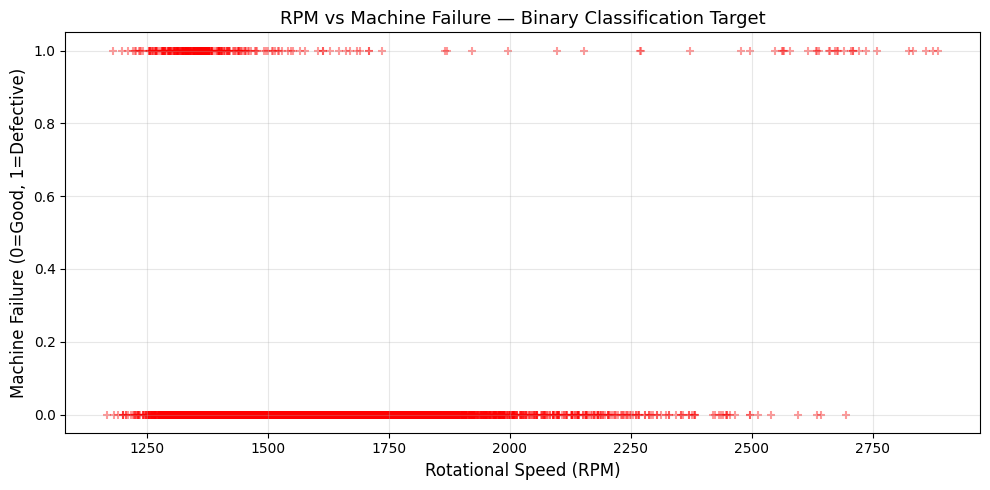

Machine Failure value counts:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure rate: 3.39%


In [216]:

plt.figure(figsize=(10, 5))
plt.scatter(df_encoded['Rotational speed [rpm]'],
            df_encoded['Machine failure'],
            marker='+', color='red', alpha=0.4)

plt.xlabel('Rotational Speed (RPM)', fontsize=12)
plt.ylabel('Machine Failure (0=Good, 1=Defective)', fontsize=12)
plt.title('RPM vs Machine Failure — Binary Classification Target', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Class distribution check
print("Machine Failure value counts:")
print(df_encoded['Machine failure'].value_counts())
print(f"\nFailure rate: {df_encoded['Machine failure'].mean()*100:.2f}%")


In [217]:

y_cls = df_encoded['Machine failure']
from sklearn.model_selection import train_test_split

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X, y_cls, test_size=0.2, random_state=42
)

print(f"Training samples  : {X_train_cls.shape[0]}")
print(f"Test samples      : {X_test_cls.shape[0]}")
print(f"\nTraining set failure count:")
print(y_train_cls.value_counts())
print(f"\nTest set failure count:")
print(y_test_cls.value_counts())

Training samples  : 8000
Test samples      : 2000

Training set failure count:
Machine failure
0    7722
1     278
Name: count, dtype: int64

Test set failure count:
Machine failure
0    1939
1      61
Name: count, dtype: int64


In [218]:
from sklearn.linear_model import LogisticRegression
model_cls = LogisticRegression(max_iter=1000)
model_cls.fit(X_train_cls, y_train_cls)
print("Logistic Regression model trained successfully.")
print(f"\nModel Coefficients (one per feature):")
for feature, coef in zip(X.columns, model_cls.coef_[0]):
    print(f"  {feature:<35}: {coef:.6f}")
print(f"\nModel Intercept: {model_cls.intercept_[0]:.6f}")

Logistic Regression model trained successfully.

Model Coefficients (one per feature):
  Rotational speed [rpm]             : 0.011401
  Torque [Nm]                        : 0.276860
  Tool wear [min]                    : 0.013081
  Air temperature [K]                : 0.301438
  Type_L                             : 0.607613
  Type_M                             : 0.336241

Model Intercept: -125.666030


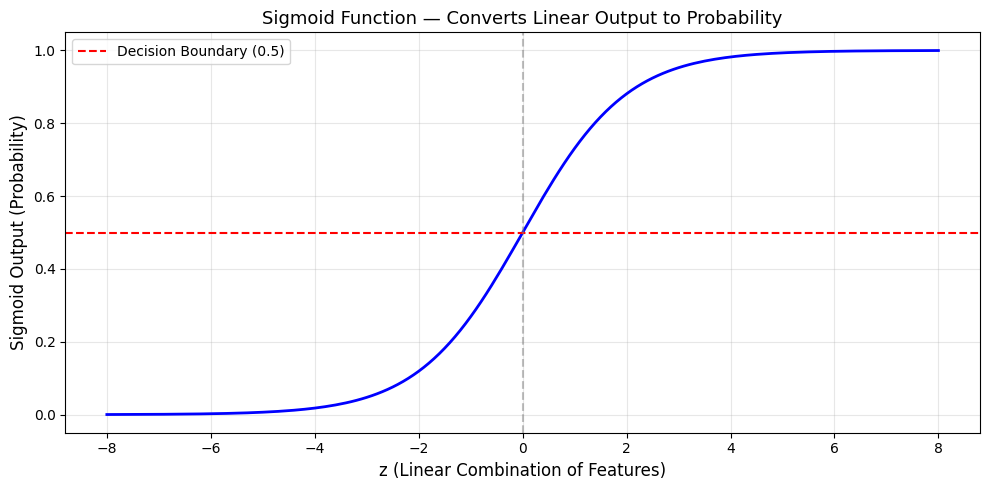

SIGMOID FUNCTION EXPLAINED:
  z = coef1*RPM + coef2*Torque + ... + intercept
  probability = 1 / (1 + e^(-z))
  if probability >= 0.5 → predict Defective (1)
  if probability < 0.5  → predict Good (0)


In [219]:
import math

def sigmoid(x):
    return 1 / (1 + math.exp(-x))

x_vals = [i * 0.1 for i in range(-80, 81)]
y_vals = [sigmoid(x) for x in x_vals]

plt.figure(figsize=(10, 5))
plt.plot(x_vals, y_vals, color='blue', linewidth=2)
plt.axhline(y=0.5, color='red', linestyle='--', label='Decision Boundary (0.5)')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('z (Linear Combination of Features)', fontsize=12)
plt.ylabel('Sigmoid Output (Probability)', fontsize=12)
plt.title('Sigmoid Function — Converts Linear Output to Probability', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("SIGMOID FUNCTION EXPLAINED:")
print("  z = coef1*RPM + coef2*Torque + ... + intercept")
print("  probability = 1 / (1 + e^(-z))")
print("  if probability >= 0.5 → predict Defective (1)")
print("  if probability < 0.5  → predict Good (0)")

In [220]:
def prediction_function(rpm, torque, tool_wear, air_temp, type_L, type_M):
   
    coefs = model_cls.coef_[0]
    intercept = model_cls.intercept_[0]
    
    z = (coefs[0] * rpm +
         coefs[1] * torque +
         coefs[2] * tool_wear +
         coefs[3] * air_temp +
         coefs[4] * type_L +
         coefs[5] * type_M +
         intercept)
    
    probability = sigmoid(z)
    return probability

prob1 = prediction_function(1500, 40, 50, 300, 0, 1)
print(f"Test 1 — Normal conditions (Type M, 1500 RPM, 40 Nm, 50 min wear, 300K air):")
print(f"  Failure probability: {prob1:.4f} ({prob1*100:.2f}%)")
print(f"  Prediction: {'DEFECTIVE' if prob1 >= 0.5 else 'GOOD'}")
print()

prob2 = prediction_function(2500, 70, 250, 310, 0, 0)
print(f"Test 2 — Extreme conditions (Type H, 2500 RPM, 70 Nm, 250 min wear, 310K air):")
print(f"  Failure probability: {prob2:.4f} ({prob2*100:.2f}%)")
print(f"  Prediction: {'DEFECTIVE' if prob2 >= 0.5 else 'GOOD'}")

Test 1 — Normal conditions (Type M, 1500 RPM, 40 Nm, 50 min wear, 300K air):
  Failure probability: 0.0023 (0.23%)
  Prediction: GOOD

Test 2 — Extreme conditions (Type H, 2500 RPM, 70 Nm, 250 min wear, 310K air):
  Failure probability: 1.0000 (100.00%)
  Prediction: DEFECTIVE


In [221]:

y_pred_cls = model_cls.predict(X_test_cls)
y_prob_cls = model_cls.predict_proba(X_test_cls)
accuracy = model_cls.score(X_test_cls, y_test_cls)

print(f"Model Accuracy on Test Set: {accuracy*100:.2f}%")
print()

print("Actual vs Predicted (first 10 test rows):")
print(f"{'Row':<5} {'Actual':<10} {'Predicted':<12} {'Prob(Defective)'}")
print("-" * 45)
for i in range(10):
    actual = y_test_cls.values[i]
    predicted = y_pred_cls[i]
    prob_defective = y_prob_cls[i][1]
    status = "✓" if actual == predicted else "✗"
    print(f"{i:<5} {actual:<10} {predicted:<12} {prob_defective:.4f}  {status}")

Model Accuracy on Test Set: 97.40%

Actual vs Predicted (first 10 test rows):
Row   Actual     Predicted    Prob(Defective)
---------------------------------------------
0     0          0            0.0138  ✓
1     1          0            0.0201  ✗
2     0          0            0.0049  ✓
3     0          0            0.0026  ✓
4     0          0            0.0129  ✓
5     1          0            0.0241  ✗
6     0          0            0.0539  ✓
7     0          0            0.1153  ✓
8     0          0            0.0032  ✓
9     0          0            0.0004  ✓


### Step 6.7 — Confusion Matrix (Core Research Requirement)

In [222]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test_cls, y_pred_cls)
print("Raw Confusion Matrix:")
print(cm)
print()

# Extract individual values
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

print(f"True Negatives  (TN) — Correctly predicted GOOD      : {TN}")
print(f"False Positives (FP) — Predicted DEFECTIVE, was GOOD : {FP}")
print(f"False Negatives (FN) — Predicted GOOD, was DEFECTIVE : {FN}")
print(f"True Positives  (TP) — Correctly predicted DEFECTIVE : {TP}")

Raw Confusion Matrix:
[[1930    9]
 [  43   18]]

True Negatives  (TN) — Correctly predicted GOOD      : 1930
False Positives (FP) — Predicted DEFECTIVE, was GOOD : 9
False Negatives (FN) — Predicted GOOD, was DEFECTIVE : 43
True Positives  (TP) — Correctly predicted DEFECTIVE : 18


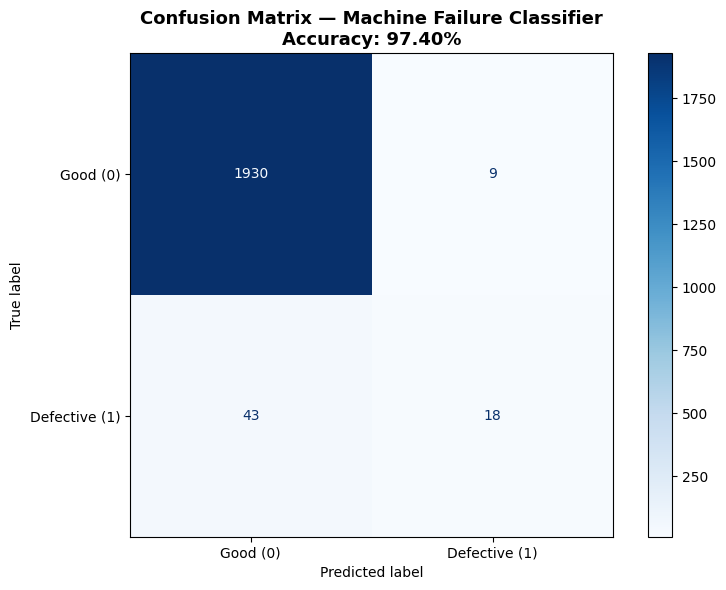

In [223]:
# Visual confusion matrix — professional format
fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Good (0)', 'Defective (1)'])

disp.plot(ax=ax, colorbar=True, cmap='Blues')

ax.set_title('Confusion Matrix — Machine Failure Classifier\n'
             f'Accuracy: {accuracy*100:.2f}%', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [224]:
from sklearn.metrics import classification_report

print("DETAILED CLASSIFICATION REPORT:")
print(classification_report(y_test_cls, y_pred_cls,
                             target_names=['Good (0)', 'Defective (1)']))

DETAILED CLASSIFICATION REPORT:
               precision    recall  f1-score   support

     Good (0)       0.98      1.00      0.99      1939
Defective (1)       0.67      0.30      0.41        61

     accuracy                           0.97      2000
    macro avg       0.82      0.65      0.70      2000
 weighted avg       0.97      0.97      0.97      2000

